In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf


print('loaded!')

loaded!


---
---
# Coffee Shop Breakdown

This data is pulled from Kaggle and can be found here: https://www.kaggle.com/datasets/ahmedabbas757/coffee-sales


I have already created a SQL Database with 149,116 entries between 3 stores. The data exported from SQL contains only information from store 8. It also excludes the store id (8) and store location (Hell's Kitchen)

Column Descriptions:

transaction_id : Unique sequential ID representing an individual transaction

transaction_date : Date of the transaction (MM/DD/YY)

transaction_time : Timestamp of the transaction (HH:MM:SS)

transaction_qty : Quantity of items sold

store_id : Unique ID of the coffee shop where the transaction took place

store_location : Location of the coffee shop where the transaction took place

product_id : Unique ID of the product sold

unit_price : Retail price of the product sold

product_category : Description of the product category

product_type : Description of the product type

product_detail : Description of the product detail

# Project Purpose

The purpose of this analysis is to identify drinks that are key drivers of gross income. 

This information, alongside a store's internal data on coffe production time, can inform the business' staffing decisions. For my analysis I will differentiate between Ready-to-Serve (drip, coldbrew, iced tea) and Made-to-Order (Latte, Mocha, hot tea, etc)

In [2]:
# Import dataset and show shape alongside first 5 entries
data = pd.read_csv('store_8_coffee_data.csv')
print(data.shape)
print(data.head())

(50735, 9)
   id transaction_date transaction_time  transaction_qty  product_id  \
0  18       2023-01-01         08:00:18                1          42   
1  19       2023-01-01         08:00:39                2          59   
2  20       2023-01-01         08:11:45                1          61   
3  21       2023-01-01         08:17:27                2          33   
4  24       2023-01-01         08:29:38                1          56   

   unit_price    product_category           product_type  \
0        2.50                 Tea      Brewed herbal tea   
1        4.50  Drinking Chocolate          Hot chocolate   
2        4.75  Drinking Chocolate          Hot chocolate   
3        3.50              Coffee  Gourmet brewed coffee   
4        2.55                 Tea        Brewed Chai tea   

                   product_detail  
0                Lemon Grass Rg\r  
1             Dark chocolate Lg\r  
2  Sustainably Grown Organic Lg\r  
3                   Ethiopia Lg\r  
4      Spicy Ey

# Exploratory Analysis

In [3]:
# Exploratory
# Check column names, column datatypes, and missing data (none)
print(data.columns)
print(data.dtypes)
print(data.isna().sum())

Index(['id', 'transaction_date', 'transaction_time', 'transaction_qty',
       'product_id', 'unit_price', 'product_category', 'product_type',
       'product_detail'],
      dtype='object')
id                    int64
transaction_date     object
transaction_time     object
transaction_qty       int64
product_id            int64
unit_price          float64
product_category     object
product_type         object
product_detail       object
dtype: object
id                  0
transaction_date    0
transaction_time    0
transaction_qty     0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


In [4]:
print(data.describe())

                  id  transaction_qty    product_id    unit_price
count   50735.000000     50735.000000  50735.000000  50735.000000
mean    74411.727762         1.413955     48.098157      3.394218
std     43056.810596         0.500879     18.440678      2.777859
min        18.000000         1.000000      1.000000      0.800000
25%     37444.500000         1.000000     33.000000      2.500000
50%     74010.000000         1.000000     47.000000      3.000000
75%    111983.500000         2.000000     60.000000      3.750000
max    149456.000000         8.000000     87.000000     45.000000


In [5]:
# Create column transaction_datetime to assist with analysis
data['transaction_datetime'] = pd.to_datetime(
    data['transaction_date'].astype(str) + ' ' + data['transaction_time'].astype(str)
)

#adjust transaction_date
data['transaction_date'] = pd.to_datetime(data['transaction_date'])
data['transaction_date'] = data['transaction_date'].dt.date

---
---
# Validation
---
---

## Check each Column

### Product Category & Type

In [6]:
print(data[data['product_detail'].isin(['Latte', 'Latte Rg'])])

Empty DataFrame
Columns: [id, transaction_date, transaction_time, transaction_qty, product_id, unit_price, product_category, product_type, product_detail, transaction_datetime]
Index: []


In [7]:
# Check unique categories
print(data['product_category'].unique())

# to remove - categories like food and beans
category_to_remove = ['Bakery', 'Flavours', 'Packaged Chocolate', 'Branded', 'Coffee beans']
drink_data = data[~data['product_category'].isin(category_to_remove)].copy()

print(drink_data.shape)


# Check Type
print(drink_data['product_type'].unique())

# All Good
# I made the decision to remove things like Beans. While they are important to a coffee shop they don't require any additional labour to sell compared to thinks like a Latte

['Tea' 'Drinking Chocolate' 'Coffee' 'Bakery' 'Flavours' 'Coffee beans'
 'Loose Tea' 'Packaged Chocolate' 'Branded']
(39712, 10)
['Brewed herbal tea' 'Hot chocolate' 'Gourmet brewed coffee'
 'Brewed Chai tea' 'Barista Espresso' 'Drip coffee' 'Brewed Green tea'
 'Premium brewed coffee' 'Brewed Black tea' 'Organic brewed coffee'
 'Chai tea' 'Black tea' 'Herbal tea' 'Green tea']


### Product Detail

In [8]:
# Product Detail all ends in \r. use strip
#print(data['product_detail'].unique())

# remove \r at end
drink_data['product_detail'] = drink_data['product_detail'].str.rstrip('\r')

# Verify
print(f'Number of Unique entries in product_detail: {len(drink_data['product_detail'].unique())}')
print(drink_data['product_detail'].value_counts())

# check for unique without size restriction
# we get 19
product_detail = drink_data['product_detail'].str.replace(r'\s(Lg|Rg|Sm)$', '', regex=True)
print(f'Number of products without drink sizes: {len(product_detail.unique())}')

# update drink_data without Lg|Rg|Sm
drink_data['product_detail_nosize'] = drink_data['product_detail'].str.replace(r'\s(Lg|Rg|Sm)$', '', regex=True)


Number of Unique entries in product_detail: 49
product_detail
Ouro Brasileiro shot            1363
Morning Sunrise Chai Rg         1058
Serenity Green Tea Rg           1054
Sustainably Grown Organic Lg    1039
Earl Grey Rg                    1020
Our Old Time Diner Blend Sm     1018
Ethiopia Lg                     1017
English Breakfast Lg            1016
Brazilian Lg                    1014
Traditional Blend Chai Rg       1007
Brazilian Rg                     994
Brazilian Sm                     990
Cappuccino                       987
Latte Rg                         985
Ethiopia Rg                      980
Latte                            975
Our Old Time Diner Blend Rg      955
Columbian Medium Roast Rg        955
Spicy Eye Opener Chai Lg         955
Dark chocolate Lg                951
Lemon Grass Lg                   945
Espresso shot                    943
Serenity Green Tea Lg            937
Traditional Blend Chai Lg        937
Peppermint Rg                    934
Morning Sunri

### Unit Price

[ 2.5   4.5   4.75  3.5   2.55  3.75  3.    4.25  3.1   2.    2.2   4.
  2.45  9.5   8.95 10.95  2.1   9.25]


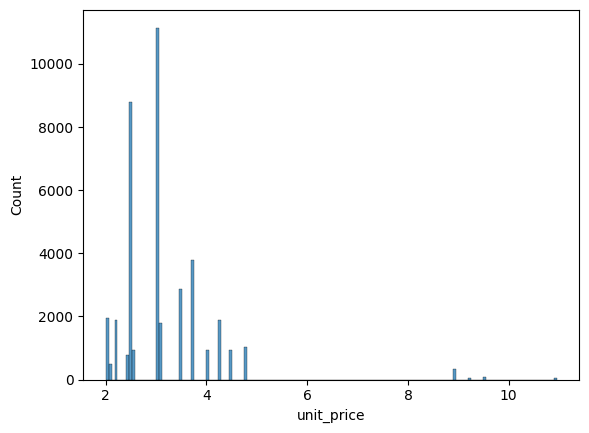

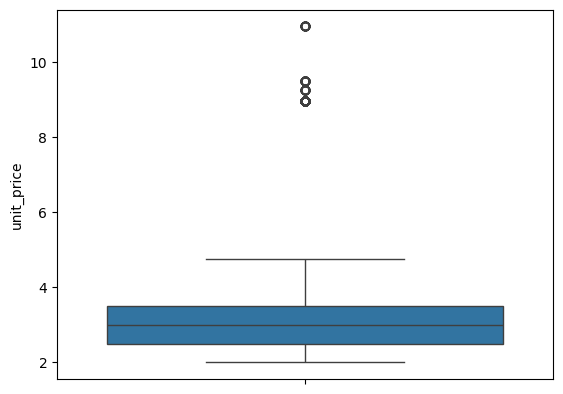

In [9]:
# 
print(drink_data['unit_price'].unique())
h = sns.histplot(drink_data['unit_price'])
plt.show()

b = sns.boxplot(drink_data['unit_price'])
plt.show()

Drinks that cost over $7 are: ['Loose Tea']
Average drink unit price: 3.1223773670427075
Most Common drink unit price: 0    3.0
Name: unit_price, dtype: float64
[ 9.5   8.95 10.95  9.25]


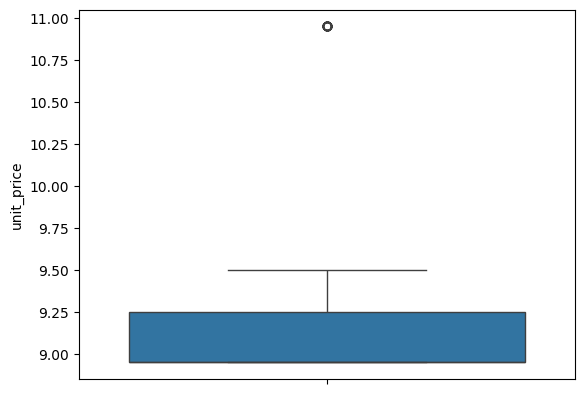

unit_price
8.95     338
9.50      68
9.25      44
10.95     35
Name: count, dtype: int64
         id transaction_date transaction_time  transaction_qty  product_id  \
2300   6731       2023-01-13         08:05:11                1          18   
4957  14534       2023-01-26         09:48:40                1          18   
8146  23823       2023-02-12         09:54:30                1          18   
8299  24261       2023-02-13         08:05:11                1          18   
8680  25131       2023-02-14         10:33:09                1          18   

      unit_price product_category product_type         product_detail  \
2300       10.95        Loose Tea     Chai tea  Spicy Eye Opener Chai   
4957       10.95        Loose Tea     Chai tea  Spicy Eye Opener Chai   
8146       10.95        Loose Tea     Chai tea  Spicy Eye Opener Chai   
8299       10.95        Loose Tea     Chai tea  Spicy Eye Opener Chai   
8680       10.95        Loose Tea     Chai tea  Spicy Eye Opener Chai   

   

In [10]:
# There appear to be outliers (drinks that cost over $8.) Let's investigate that a bit more

# this indidcated they are all Loose Tea
high_priced_drinks = drink_data[drink_data['unit_price'] > 7]
print(f'Drinks that cost over $7 are: {high_priced_drinks['product_category'].unique()}')

# It may not be an error, checking mean and mode
print(f'Average drink unit price: {drink_data['unit_price'].mean()}')
print(f'Most Common drink unit price: {drink_data['unit_price'].mode()}')

print(drink_data[drink_data['product_category'].isin(['Loose Tea'])]['unit_price'].unique())


tea = sns.boxplot(
    data=drink_data[drink_data['product_category'] == 'Loose Tea'],
    y='unit_price'
)

plt.show()

# Check tea data value counts
tea_data = drink_data[drink_data['product_category'] == 'Loose Tea']
print(tea_data['unit_price'].value_counts())

# check the high priced tea
high_tea = tea_data[tea_data['unit_price'] == 10.95] 
print(high_tea.head())

I am going to leave all of them in. While $10.95 feels high for the dataset they are all Chai Teas and Spicy Eye Opener Chai which leads me to believe it's a special drink. 

With 35 entries it's not a majority but still a decent number of sales

### Transaction QTY

transaction_qty
1    20067
2    19645
Name: count, dtype: int64


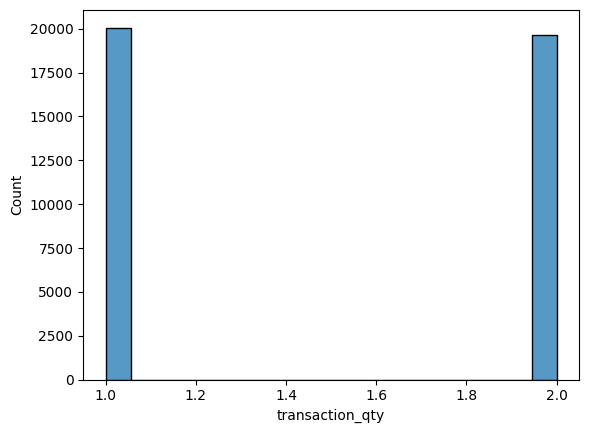

In [11]:
# All Good
sns.histplot(drink_data['transaction_qty'])
print(drink_data['transaction_qty'].value_counts())


### Transaction Time

In [12]:
print(drink_data['transaction_time'].dtype)
# needs to be time

drink_data['hour'] = pd.to_datetime(
    drink_data['transaction_time']).dt.hour

# shows we are open between 6 am and 9pm
print(drink_data['transaction_time'].min(), drink_data['transaction_time'].max())
print(drink_data['hour'].unique())

object


C:\Users\crees\AppData\Local\Temp\ipykernel_21920\3484225396.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  drink_data['hour'] = pd.to_datetime(


06:30:10 20:59:32
[ 8  9 10 11 12 13 14 15 16 17 18 19 20  6  7]


In [13]:
# I want to view in smaller increments than every hour though

# date_time with floor funciton
drink_data['time_10min'] = (
    drink_data['transaction_datetime']
    .dt.floor('15min')
)

# extract the time alone
drink_data['hour_minute'] = (
    drink_data['time_10min']
    .dt.strftime('%H:%M')
)
print(drink_data['hour_minute'])

0        08:00
1        08:00
2        08:00
3        08:15
4        08:15
         ...  
50729    20:00
50730    20:15
50731    20:15
50732    20:30
50733    20:45
Name: hour_minute, Length: 39712, dtype: object


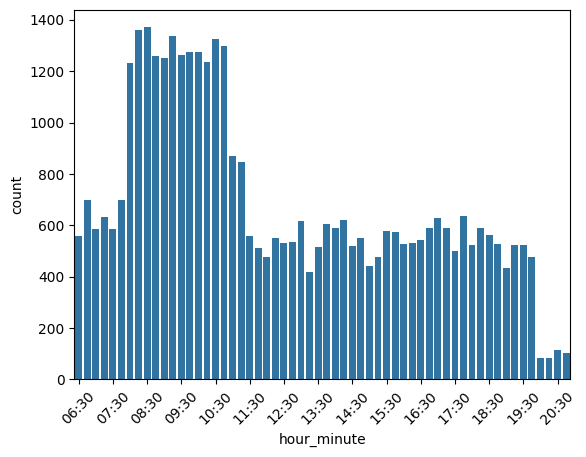

In [14]:
drink_data['hour_minute'] = pd.Categorical(
    drink_data['hour_minute'],
    categories=sorted(drink_data['hour_minute'].unique()),
    ordered=True
)


ax = sns.countplot(data = drink_data, x = 'hour_minute')

# Show hourly ticks
ticks = range(0, len(drink_data['hour_minute'].cat.categories), 4)
labels = drink_data['hour_minute'].cat.categories[::4]

ax.set_xticks(ticks)
ax.set_xticklabels(labels, rotation=45)
plt.show()

### Transaction Date

object
2023-01-01 00:00:00 2023-06-30 00:00:00
day_of_week
Friday       5842
Tuesday      5808
Thursday     5772
Sunday       5694
Monday       5628
Wednesday    5581
Saturday     5387
Name: count, dtype: int64


<Axes: xlabel='day_of_week', ylabel='count'>

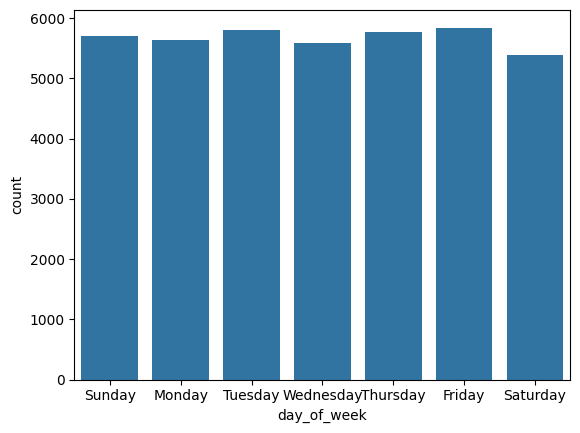

In [15]:
print(drink_data['transaction_date'].dtype)

# change to datetime
drink_data['transaction_date'] = pd.to_datetime(
    drink_data['transaction_date']
)

# checking it takes course over 6 months (jan 1, 2023 thru june 30, 2023)
print(drink_data['transaction_date'].min(), drink_data['transaction_date'].max())

# pull day of week
drink_data['day_of_week'] = drink_data['transaction_date'].dt.day_name()

# view spread
print(drink_data['day_of_week'].value_counts())
sns.countplot(x = drink_data['day_of_week'])


### Add Total_Sale

In [16]:
# multiply qty by unit_price
drink_data['total_sale'] = round(drink_data['transaction_qty'] * drink_data['unit_price'] ,2)
print(drink_data.head(2))

   id transaction_date transaction_time  transaction_qty  product_id  \
0  18       2023-01-01         08:00:18                1          42   
1  19       2023-01-01         08:00:39                2          59   

   unit_price    product_category       product_type     product_detail  \
0         2.5                 Tea  Brewed herbal tea     Lemon Grass Rg   
1         4.5  Drinking Chocolate      Hot chocolate  Dark chocolate Lg   

  transaction_datetime product_detail_nosize  hour          time_10min  \
0  2023-01-01 08:00:18           Lemon Grass     8 2023-01-01 08:00:00   
1  2023-01-01 08:00:39        Dark chocolate     8 2023-01-01 08:00:00   

  hour_minute day_of_week  total_sale  
0       08:00      Sunday         2.5  
1       08:00      Sunday         9.0  


---
---
# Analysis
---
___

In [17]:
print(drink_data.head(2))

   id transaction_date transaction_time  transaction_qty  product_id  \
0  18       2023-01-01         08:00:18                1          42   
1  19       2023-01-01         08:00:39                2          59   

   unit_price    product_category       product_type     product_detail  \
0         2.5                 Tea  Brewed herbal tea     Lemon Grass Rg   
1         4.5  Drinking Chocolate      Hot chocolate  Dark chocolate Lg   

  transaction_datetime product_detail_nosize  hour          time_10min  \
0  2023-01-01 08:00:18           Lemon Grass     8 2023-01-01 08:00:00   
1  2023-01-01 08:00:39        Dark chocolate     8 2023-01-01 08:00:00   

  hour_minute day_of_week  total_sale  
0       08:00      Sunday         2.5  
1       08:00      Sunday         9.0  


Couple things of note before I start
- Day of week seems to have no impact on number of sales. 
- 8, 9, 10am are by far the highest sellers in terms of drink count
- I still want to see which drink accounts for most sales (we have only seen count, not sale amount)
- I still want to see how the day of the week affects popular times (weekday afternoons may be slow but weekend afternoons may be high)

### Day of week vs time

<Axes: xlabel='hour', ylabel='count'>

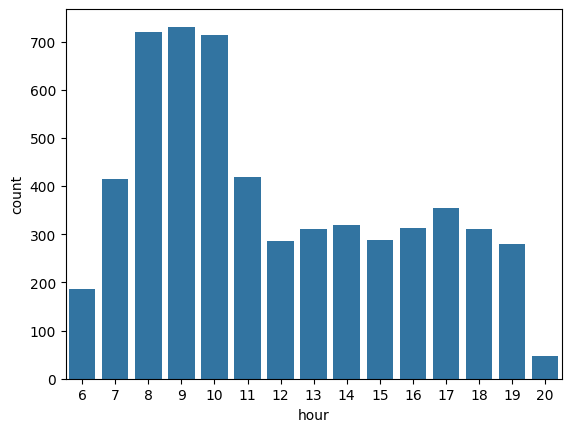

In [18]:
#SUNDAY
sunday_data = drink_data[drink_data['day_of_week'] == 'Sunday']
sns.countplot(
    data=sunday_data,
    x='hour'
)

<Axes: xlabel='hour', ylabel='count'>

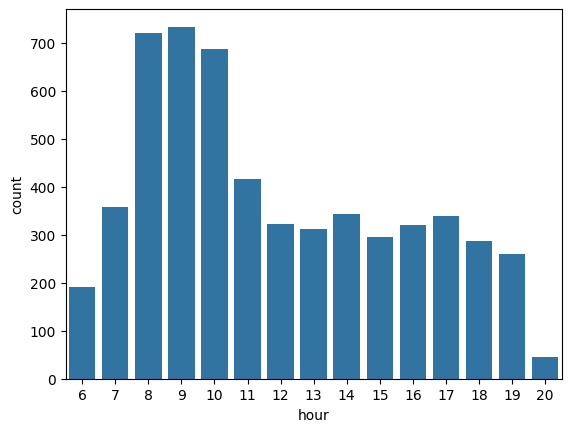

In [19]:
#MONDAY
monday_data = drink_data[drink_data['day_of_week'] == 'Monday']
sns.countplot(
    data=monday_data,
    x='hour'
)

<Axes: xlabel='hour', ylabel='count'>

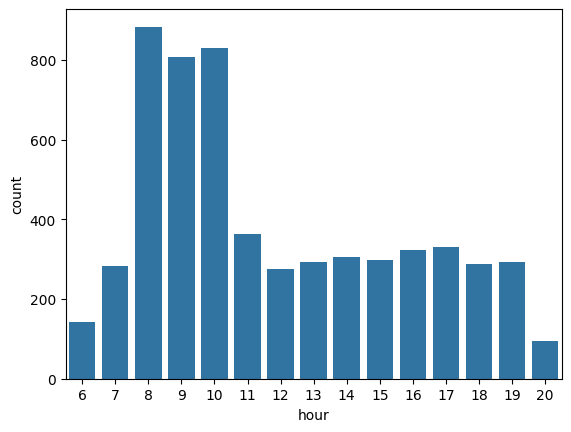

In [20]:
#TUESDAY
tuesday_data = drink_data[drink_data['day_of_week'] == 'Tuesday']
sns.countplot(
    data=tuesday_data,
    x='hour'
)

<Axes: xlabel='hour', ylabel='count'>

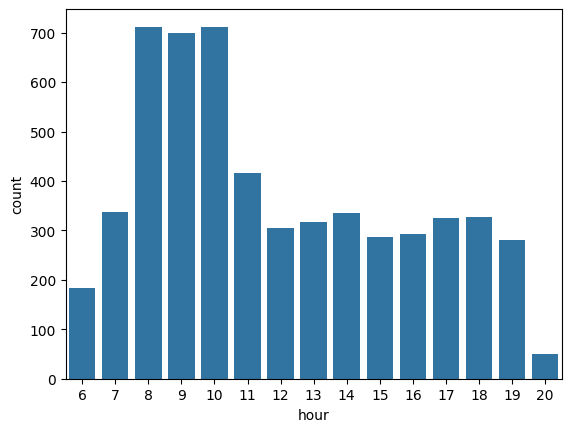

In [21]:
#WEDNESDAY
wednesday_data = drink_data[drink_data['day_of_week'] == 'Wednesday']
sns.countplot(
    data=wednesday_data,
    x='hour'
)

<Axes: xlabel='hour', ylabel='count'>

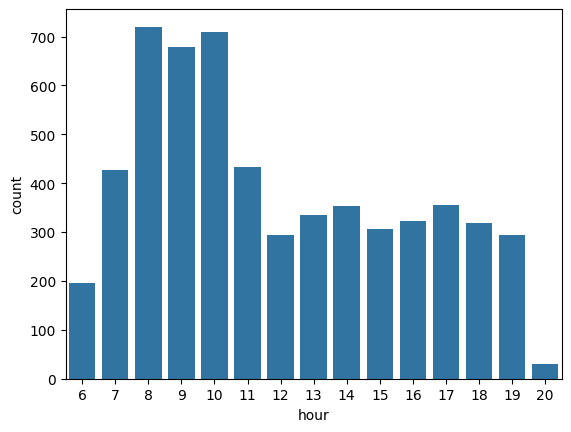

In [22]:
#THURSDAY
thursday_data = drink_data[drink_data['day_of_week'] == 'Thursday']
sns.countplot(
    data=thursday_data,
    x='hour'
)

<Axes: xlabel='hour', ylabel='count'>

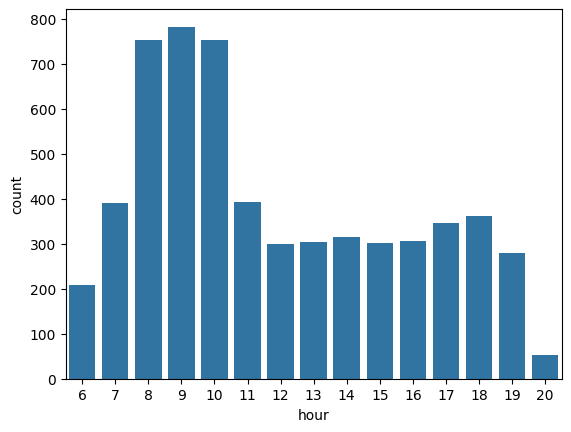

In [23]:
#FRIDAY
friday_data = drink_data[drink_data['day_of_week'] == 'Friday']
sns.countplot(
    data=friday_data,
    x='hour'
)

<Axes: xlabel='hour', ylabel='count'>

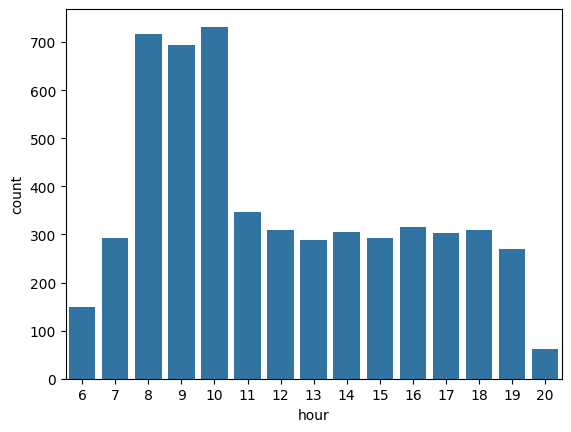

In [24]:
#SATURDAY
saturday_data = drink_data[drink_data['day_of_week'] == 'Saturday']
sns.countplot(
    data=saturday_data,
    x='hour'
)

There are no strong differences between time of day on any day of the week

In [25]:
# Checking for highest Selling Product Cateogry and type
category_data = drink_data[['id', 'product_category', 'total_sale']]
category_sellers = drink_data.groupby(by ='product_category')['total_sale'].sum()
print(category_sellers)
print(drink_data['product_category'].unique())

# This does not have distinction between coffee types. I need to use Detail instead

# detail_data 
detail_sales = (drink_data.groupby(by = 'product_type', as_index=False)['total_sale']
        .sum().sort_values('total_sale', ascending = False)
)
print(detail_sales)

product_category
Coffee                91222.65
Drinking Chocolate    23586.25
Loose Tea              4461.35
Tea                   64701.30
Name: total_sale, dtype: float64
['Tea' 'Drinking Chocolate' 'Coffee' 'Loose Tea']
             product_type  total_sale
0        Barista Espresso    32420.20
3         Brewed Chai tea    25645.30
11          Hot chocolate    23586.25
8   Gourmet brewed coffee    23010.10
2        Brewed Black tea    15575.50
5       Brewed herbal tea    15263.00
12  Organic brewed coffee    13114.00
13  Premium brewed coffee    11927.85
7             Drip coffee    10750.50
4        Brewed Green tea     8217.50
6                Chai tea     1727.35
10             Herbal tea     1261.95
1               Black tea     1065.05
9               Green tea      407.00


In [26]:
# add prep_method (ready-to-serve vs made-to-order)
# Brewed implies it was pre-made (like brewed black tea) while black tea is made to order (likely steeped at time of order?)

# Dictionary to map and create new column
drink_mapping = {
    'Barista Espresso': 'made_to_order',
    'Brewed Chai tea': 'ready_to_serve',
    'Hot chocolate': 'made_to_order',
    'Gourmet brewed coffee': 'made_to_order',
    'Brewed Black tea': 'ready_to_serve',
    'Brewed herbal tea': 'ready_to_serve',
    'Organic brewed coffee': 'ready_to_serve',
    'Premium brewed coffee': 'ready_to_serve',
    'Drip coffee': 'ready_to_serve',
    'Brewed Green tea': 'ready_to_serve',
    'Chai tea': 'made_to_order',
    'Herbal tea': 'made_to_order',
    'Black tea': 'made_to_order',
    'Green tea': 'made_to_order'

}

drink_data['prep_method'] = (drink_data['product_type']
    .map(drink_mapping)
    .fillna('other')
)
print(detail_sales)

             product_type  total_sale
0        Barista Espresso    32420.20
3         Brewed Chai tea    25645.30
11          Hot chocolate    23586.25
8   Gourmet brewed coffee    23010.10
2        Brewed Black tea    15575.50
5       Brewed herbal tea    15263.00
12  Organic brewed coffee    13114.00
13  Premium brewed coffee    11927.85
7             Drip coffee    10750.50
4        Brewed Green tea     8217.50
6                Chai tea     1727.35
10             Herbal tea     1261.95
1               Black tea     1065.05
9               Green tea      407.00


In [27]:
# prep time
prep_mapping = {
    'ready_to_serve': 1,
    'made_to_order': 2.75
}

drink_data['prep_time'] = (drink_data['prep_method']
                           .map(prep_mapping))

drink_data['estimated_labor_min'] = drink_data['prep_time'] * drink_data['transaction_qty']

In [28]:
# isolate each day again with prep_time
sunday_data = drink_data[drink_data['day_of_week'] == 'Sunday']
monday_data = drink_data[drink_data['day_of_week'] == 'Monday']
tuesday_data = drink_data[drink_data['day_of_week'] == 'Tuesday']
wednesday_data = drink_data[drink_data['day_of_week'] == 'Wednesday']
thursday_data = drink_data[drink_data['day_of_week'] == 'Thursday']
friday_data = drink_data[drink_data['day_of_week'] == 'Friday']
saturday_data = drink_data[drink_data['day_of_week'] == 'Saturday']

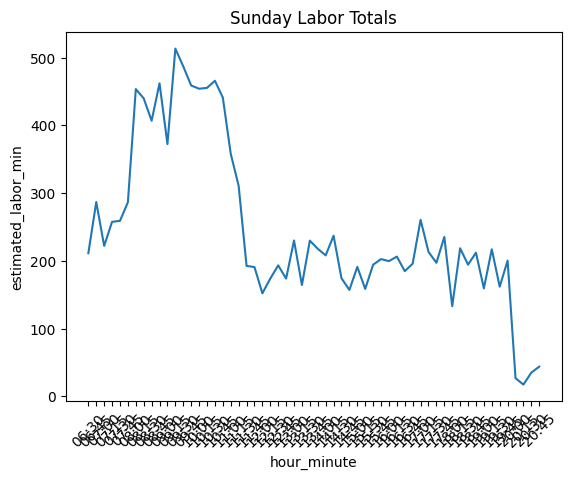

In [29]:
#SUNDAY
sns.lineplot(
    data=(sunday_data.groupby('hour_minute', observed=False)['estimated_labor_min'].sum().reset_index()),
    x='hour_minute',
    y='estimated_labor_min'
)
plt.title("Sunday Labor Totals")
plt.xticks(rotation=45)
plt.show()


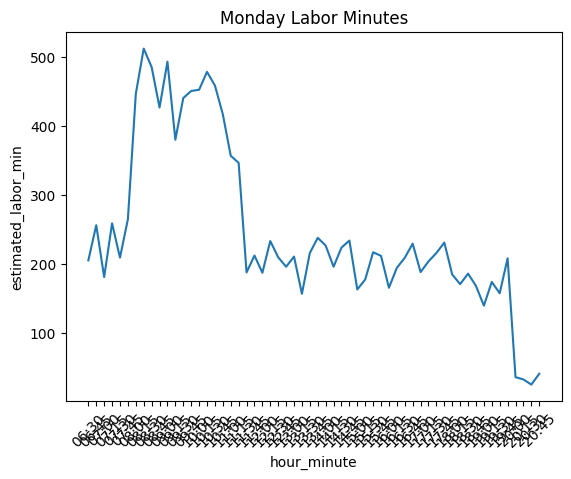

In [30]:
#MONDAY
sns.lineplot(
    data=(monday_data.groupby('hour_minute', observed=False)['estimated_labor_min'].sum().reset_index()),
    x='hour_minute',
    y='estimated_labor_min'
)

plt.title('Monday Labor Minutes')
plt.xticks(rotation=45)
plt.show()


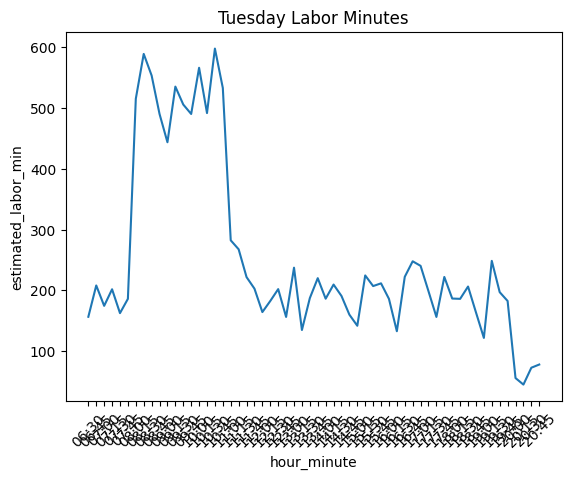

In [31]:
#TUESDAY
sns.lineplot(
    data=(tuesday_data.groupby('hour_minute', observed=False)['estimated_labor_min'].sum().reset_index()),
    x='hour_minute',
    y='estimated_labor_min'
)

plt.title('Tuesday Labor Minutes')
plt.xticks(rotation=45)
plt.show()


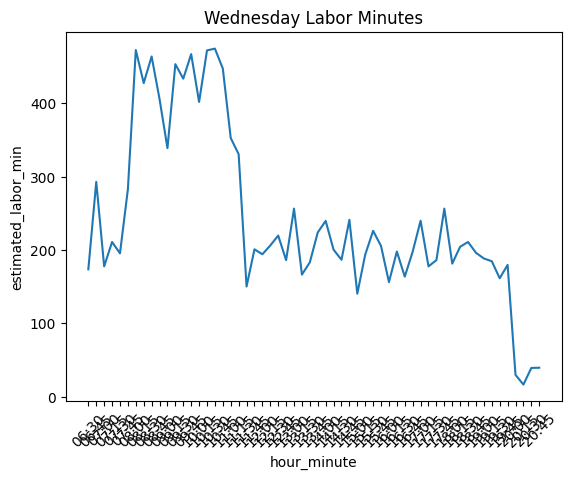

In [32]:
#WEDNESDAY
sns.lineplot(
    data=(wednesday_data.groupby('hour_minute', observed=False)['estimated_labor_min'].sum().reset_index()),
    x='hour_minute',
    y='estimated_labor_min'
)

plt.title('Wednesday Labor Minutes')
plt.xticks(rotation=45)
plt.show()


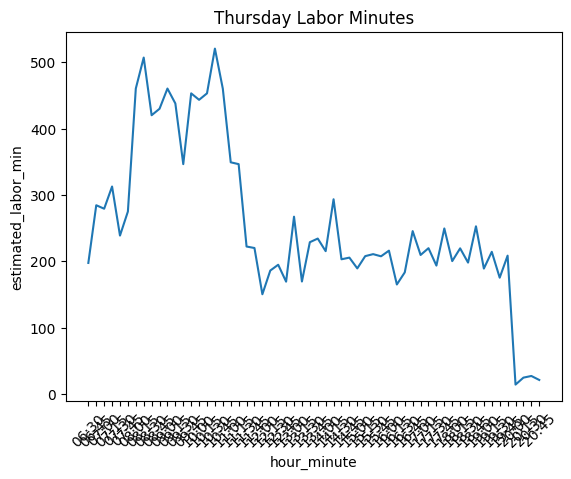

In [33]:
#THURSDAY
sns.lineplot(
    data=(thursday_data.groupby('hour_minute', observed=False)['estimated_labor_min'].sum().reset_index()),
    x='hour_minute',
    y='estimated_labor_min'
)

plt.title('Thursday Labor Minutes')
plt.xticks(rotation=45)
plt.show()


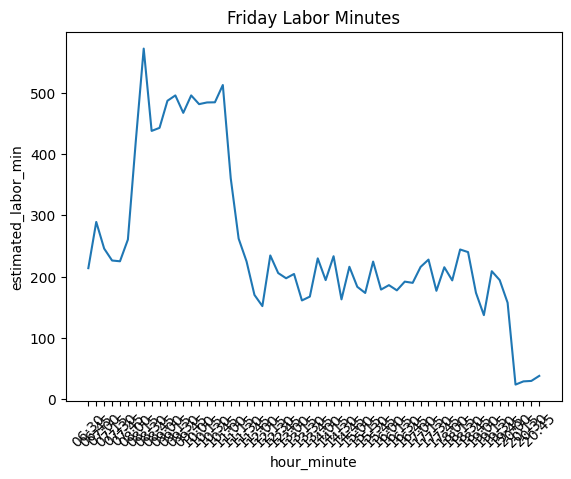

In [34]:
#FRIDAY
sns.lineplot(
    data=(friday_data.groupby('hour_minute', observed=False)['estimated_labor_min'].sum().reset_index()),
    x='hour_minute',
    y='estimated_labor_min'
)

plt.title('Friday Labor Minutes')
plt.xticks(rotation=45)
plt.show()


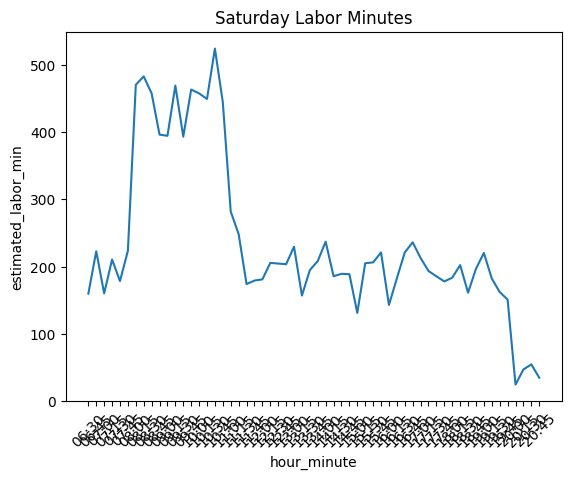

In [35]:
#SATURDAY
sns.lineplot(
    data=(saturday_data.groupby('hour_minute', observed=False)['estimated_labor_min'].sum().reset_index()),
    x='hour_minute',
    y='estimated_labor_min'
)

plt.title('Saturday Labor Minutes')
plt.xticks(rotation=45)
plt.show()


### Let's look at product details


In [36]:
# Checking for highest Selling Product Cateogry and type
category_data = drink_data[['id', 'product_category', 'total_sale']]
category_sellers = drink_data.groupby(by ='product_category')['total_sale'].sum()
print(category_sellers)
print(drink_data['product_category'].unique())

# This does not have distinction between coffee types. I need to use Detail instead

# detail_data 
detail_sales = (drink_data.groupby(by = 'product_type', as_index=False)['total_sale']
        .sum().sort_values('total_sale', ascending = False)
)

product_category
Coffee                91222.65
Drinking Chocolate    23586.25
Loose Tea              4461.35
Tea                   64701.30
Name: total_sale, dtype: float64
['Tea' 'Drinking Chocolate' 'Coffee' 'Loose Tea']


             product_type  total_sale
0        Barista Espresso    32420.20
3         Brewed Chai tea    25645.30
11          Hot chocolate    23586.25
8   Gourmet brewed coffee    23010.10
2        Brewed Black tea    15575.50
5       Brewed herbal tea    15263.00
12  Organic brewed coffee    13114.00
13  Premium brewed coffee    11927.85
7             Drip coffee    10750.50
4        Brewed Green tea     8217.50
6                Chai tea     1727.35
10             Herbal tea     1261.95
1               Black tea     1065.05
9               Green tea      407.00


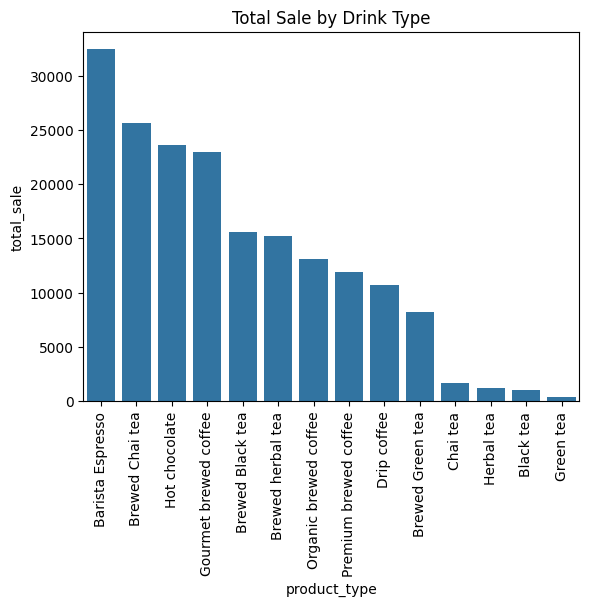

In [37]:
# Barista Espresso looks to be much higher
print(detail_sales)
ax = sns.barplot(
    data = detail_sales,
    x = 'product_type',
    y = 'total_sale'
)
plt.title('Total Sale by Drink Type')
plt.xticks(rotation = 90)
plt.show()

In [38]:
# Hypothesis test to see if Espresso is highest weekly average
weekly_sales = (
    drink_data.pivot_table(
        index = drink_data['transaction_date'].dt.to_period('W'),
        columns = 'product_type', 
        values = 'total_sale',
        aggfunc = 'sum', 
        fill_value = 0
    )
)

espresso_weekly = weekly_sales['Barista Espresso']
chai_weekly = weekly_sales['Brewed Chai tea']

t_stat, p_value = stats.ttest_ind(
    espresso_weekly, chai_weekly,
    equal_var = False,
    alternative = 'greater'
)

print(f'The t_stat value is: {t_stat}, and the p-value is {p_value}')


The t_stat value is: 2.419890488893911, and the p-value is 0.009644520504618236


From this we can conclude that with a p-value < 0.05, Daily espresso sales are higher than brewed chai tea.

First I'm going to double check Hypothesis test Assumptions of Normality, Correlation, and Independence.

It appeared in my SQL analysis that May was the highest selling month. Let's see if that holds true with an ANOVA test

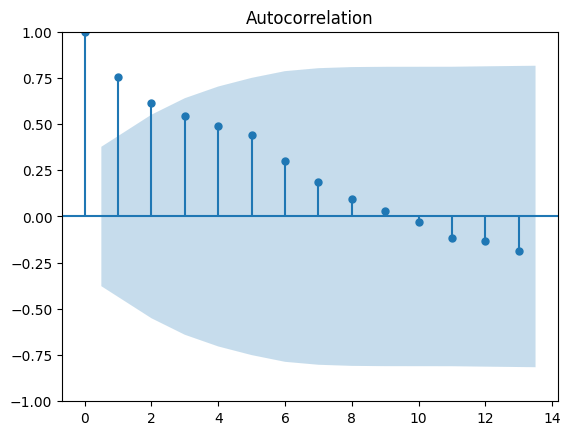

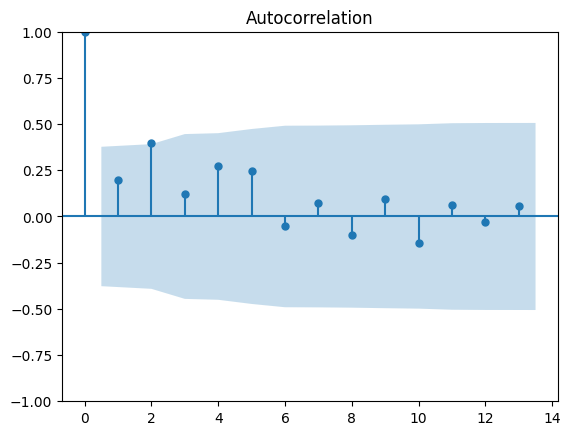

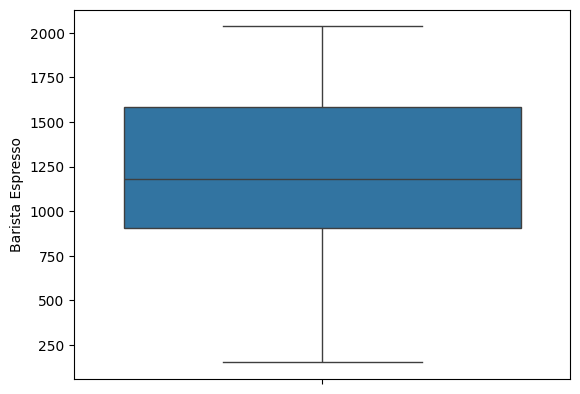

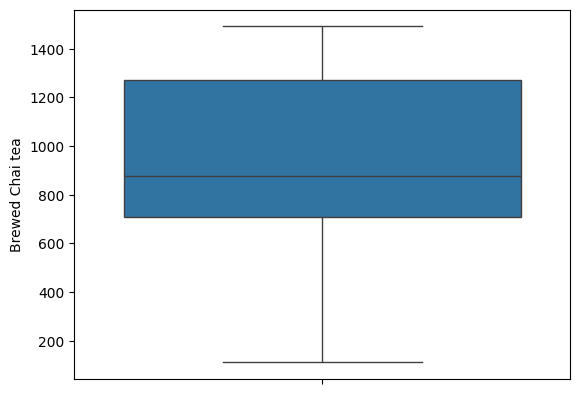

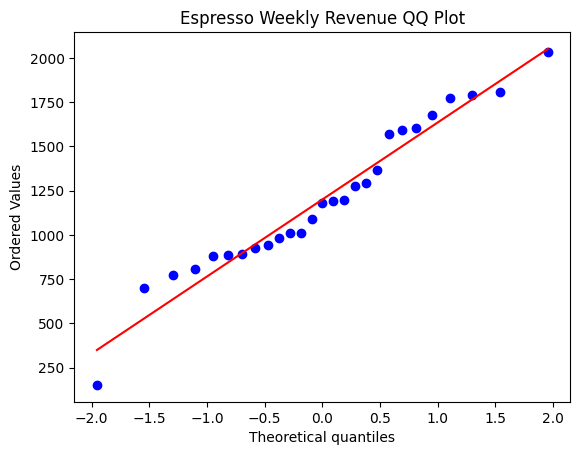

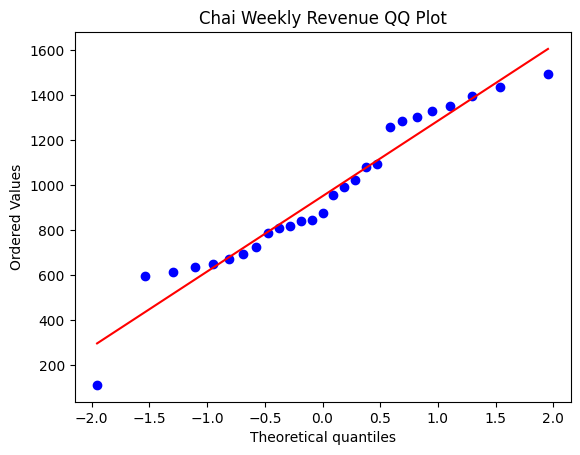

In [39]:
# Double Check Hypothesis Test Assumptions
# 
plot_acf(espresso_weekly)
plt.show()
weekly_difference = espresso_weekly - chai_weekly

plot_acf(weekly_difference)
plt.show()

sns.boxplot(espresso_weekly)
plt.show()

sns.boxplot(chai_weekly)
plt.show()

stats.probplot(espresso_weekly, dist="norm", plot=plt)
plt.title("Espresso Weekly Revenue QQ Plot")
plt.show()

stats.probplot(chai_weekly, dist="norm", plot=plt)
plt.title("Chai Weekly Revenue QQ Plot")
plt.show()

In [40]:
print(f"Espresso weekly average: ${espresso_weekly.mean():.2f}")
print(f"Chai weekly average: ${chai_weekly.mean():.2f}")
print(f"Difference: ${(espresso_weekly.mean() - chai_weekly.mean()):.2f}")

Espresso weekly average: $1200.75
Chai weekly average: $949.83
Difference: $250.92


In [41]:
len(espresso_weekly)

27

---
# Conclusion & Recommendations
---
#### Conclusions:

There is very little variance between days

Every day starts slow from 6-8 am, picks up dramatically from 8-11am, drops back down to normal until 8pm and then is practically non-existant after 9pm

Barista Espresso is the highest total selling drink. A one-tailed Hypothesis Test proved that it's also the highest weekly average with a t-stat of 2.42 and a p-value of 0.0096. 

Barista Espresso generated an average of $250 more weekly revenue than Brewed Chai Tea



#### Recommendations on Staffing:

- Have normal staffing between 6-7:30 am but increase that number before a rush hits at 8am. Remain at the higher level until 11:30 to help with afternoon prep and then drop to a regular level at 11:30
- Either severely reduce staffing after 8pm or close completely. The total hourly sales are shown below
    - if it was only sales of pre-made drinks I would consider staying open but since 2 of the top 3 sellers after 8pm (Espresso, Hot Chocolate) require work I would advise closing. 


<Axes: xlabel='hour', ylabel='total_sale'>

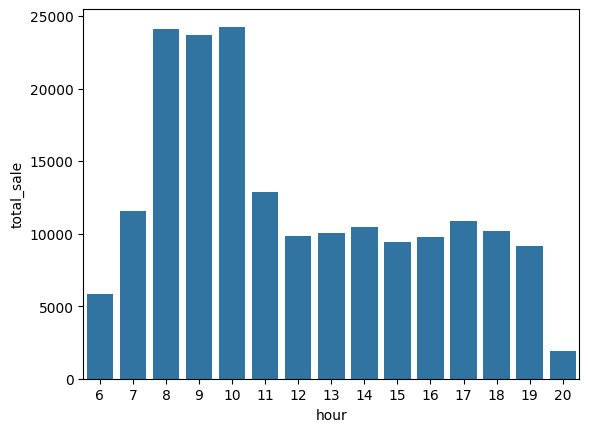

In [42]:
hourly_sales = drink_data.groupby('hour')['total_sale'].sum().reset_index()
sns.barplot(data = hourly_sales, x ='hour', y = 'total_sale')

In [43]:
late_sales = drink_data[drink_data['hour'] == 20]
print(late_sales['product_type'].value_counts())

product_type
Barista Espresso         66
Brewed Chai tea          65
Hot chocolate            48
Brewed herbal tea        42
Drip coffee              40
Brewed Black tea         34
Gourmet brewed coffee    30
Organic brewed coffee    27
Premium brewed coffee    15
Brewed Green tea         15
Chai tea                  2
Name: count, dtype: int64


---
---
---
# Extra Work for Power BI Export

In [44]:
drink_data['month'] = (drink_data['transaction_date'].dt.month_name())
drink_data['month_number'] = drink_data['transaction_date'].dt.month

In [45]:
print(drink_data.head(2))

   id transaction_date transaction_time  transaction_qty  product_id  \
0  18       2023-01-01         08:00:18                1          42   
1  19       2023-01-01         08:00:39                2          59   

   unit_price    product_category       product_type     product_detail  \
0         2.5                 Tea  Brewed herbal tea     Lemon Grass Rg   
1         4.5  Drinking Chocolate      Hot chocolate  Dark chocolate Lg   

  transaction_datetime  ... hour          time_10min hour_minute day_of_week  \
0  2023-01-01 08:00:18  ...    8 2023-01-01 08:00:00       08:00      Sunday   
1  2023-01-01 08:00:39  ...    8 2023-01-01 08:00:00       08:00      Sunday   

  total_sale     prep_method prep_time  estimated_labor_min    month  \
0        2.5  ready_to_serve      1.00                  1.0  January   
1        9.0   made_to_order      2.75                  5.5  January   

  month_number  
0            1  
1            1  

[2 rows x 21 columns]


In [46]:
print(drink_data.head())
export_df = drink_data[['transaction_date', 'transaction_time', 'transaction_qty', 'unit_price', 'product_category', 'product_type', \
                        'product_detail_nosize', 'hour', 'hour_minute', 'day_of_week', 'total_sale', 'prep_method', 'estimated_labor_min','month_number', 'month']].copy()

export_df.to_csv('coffee_data_for_dashboard.csv')

   id transaction_date transaction_time  transaction_qty  product_id  \
0  18       2023-01-01         08:00:18                1          42   
1  19       2023-01-01         08:00:39                2          59   
2  20       2023-01-01         08:11:45                1          61   
3  21       2023-01-01         08:17:27                2          33   
4  24       2023-01-01         08:29:38                1          56   

   unit_price    product_category           product_type  \
0        2.50                 Tea      Brewed herbal tea   
1        4.50  Drinking Chocolate          Hot chocolate   
2        4.75  Drinking Chocolate          Hot chocolate   
3        3.50              Coffee  Gourmet brewed coffee   
4        2.55                 Tea        Brewed Chai tea   

                 product_detail transaction_datetime  ... hour  \
0                Lemon Grass Rg  2023-01-01 08:00:18  ...    8   
1             Dark chocolate Lg  2023-01-01 08:00:39  ...    8   
2  Susta